Project Part 5: Scenario Analysis and Business Insights - Credit Card Dataset - 6/14/26 - halarc1407

Building on the optimized neural network from Project Part 4, this notebook performs scenario analysis and sensitivity analysis on the credit card approval classifier. Three realistic scenarios are simulated to understand how shifts in applicant characteristics would affect approval predictions.

In [5]:
# Import necessary libraries
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from datetime import datetime
from IPython.display import display, Markdown

todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "halarc1407"

# Load and preprocess the dataset (same pipeline as Parts 2-4)
data = pd.read_csv('Credit_card_data.csv')
for column in ['reports', 'dependents', 'active']:
    data[column] = data[column].fillna(data[column].median())
data['selfemp'] = data['selfemp'].fillna(data['selfemp'].mode()[0])
data['card'] = data['card'].map({'yes': 1, 'no': 0})
data['owner'] = data['owner'].map({'yes': 1, 'no': 0})
data['selfemp'] = data['selfemp'].map({'yes': 1, 'no': 0})

display(Markdown("### Load and Preprocess Data"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
print(f"Shape: {data.shape}")
display(data.describe())

### Load and Preprocess Data

Date: 2026-06-14

Student ID: halarc1407

Shape: (1319, 12)


,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,0.775588,0.454890,33.213103,3.365376,0.068732,185.057071,0.440485,0.068992,0.994693,55.267627,0.817286,7.011372
std,0.417353,1.345217,10.142783,1.693902,0.094656,272.218917,0.496634,0.253536,1.247444,66.271746,0.386579,6.300446
min,0.000000,0.000000,0.166667,0.210000,0.000109,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,25.416670,2.243750,0.002316,4.583333,0.000000,0.000000,0.000000,12.000000,1.000000,2.000000
50%,1.000000,0.000000,31.250000,2.900000,0.038827,101.298300,0.000000,0.000000,1.000000,30.000000,1.000000,6.000000
75%,1.000000,0.000000,39.416670,4.000000,0.093617,249.035800,1.000000,0.000000,2.000000,72.000000,1.000000,11.000000
max,1.000000,14.000000,83.500000,13.500000,0.906320,3099.505000,1.000000,1.000000,6.000000,540.000000,1.000000,46.000000


In [6]:
display(Markdown("### Rebuild the Optimized Neural Network from Project Part 4"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Prepare features and target
X = data.drop('card', axis=1)
y = data['card']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Rebuild the optimized model from Part 4 (dropout + early stopping regularization)
tf.random.set_seed(42)
model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy', metrics=['accuracy'])

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=32,
                    validation_split=0.2, callbacks=[early_stop], verbose=0)

loss, acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Optimized Neural Network Test Accuracy: {acc:.4f}")
print(f"Optimized Neural Network Test Loss: {loss:.4f}")

# Baseline predictions on full dataset for comparison
X_all_scaled = scaler.transform(X)
baseline_proba = model.predict(X_all_scaled, verbose=0).flatten()
baseline_approval_rate = (baseline_proba > 0.5).mean()
print(f"\nBaseline approval rate (full dataset): {baseline_approval_rate:.4f}")
print(f"Baseline average approval probability: {baseline_proba.mean():.4f}")

### Rebuild the Optimized Neural Network from Project Part 4

Date: 2026-06-14

Student ID: halarc1407

Optimized Neural Network Test Accuracy: 0.8939
Optimized Neural Network Test Loss: 0.2051

Baseline approval rate (full dataset): 0.7733
Baseline average approval probability: 0.7761


## Scenario Development

Three realistic scenarios that could plausibly affect credit card approvals in the real world:

### Scenario 1: Economic Recession
**Assumption:** A recession causes widespread income reduction (-15%) and increased credit utilization (+25% in share of income spent on credit).  
**Rationale:** During recessions like 2008 or the early COVID-19 period, applicants typically have lower take-home income and higher credit utilization as they rely more on credit to cover gaps. Testing this scenario shows how the model would behave during an economic downturn when approval risk is harder to assess.

### Scenario 2: Younger Applicant Demographic
**Assumption:** Average applicant age drops by 8 years, dependents reduced (-1), and active credit accounts reduced (-3).  
**Rationale:** Credit card issuers increasingly target younger consumers, including Gen Z applicants entering the credit market. This scenario tests how the model handles applicants with shorter credit histories and fewer existing accounts, which is important for understanding bias against thin-credit-file applicants.

### Scenario 3: Higher Income, Lower Debt Burden
**Assumption:** Income increased by 20%, expenditure share reduced by 30%, and homeownership rate increased.  
**Rationale:** This represents a market with stronger applicant financial health, similar to a tightening credit market where only well-qualified applicants apply. It also tests whether the model rewards stronger financial profiles appropriately or if it has other dominant signals.

In [7]:
display(Markdown("### Scenario Simulation"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Helper function to apply a scenario, scale, predict, and summarize
def run_scenario(X_modified, scenario_name):
    X_scaled = scaler.transform(X_modified)
    proba = model.predict(X_scaled, verbose=0).flatten()
    approval_rate = (proba > 0.5).mean()
    return {
        'scenario': scenario_name,
        'approval_rate': approval_rate,
        'avg_probability': proba.mean(),
        'predictions': proba
    }

# Scenario 1: Economic Recession
X_recession = X.copy()
X_recession['income'] = X_recession['income'] * 0.85
X_recession['share'] = X_recession['share'] * 1.25
scenario_1 = run_scenario(X_recession, 'Economic Recession')

# Scenario 2: Younger Applicant Demographic
X_younger = X.copy()
X_younger['age'] = X_younger['age'] - 8
X_younger['dependents'] = (X_younger['dependents'] - 1).clip(lower=0)
X_younger['active'] = (X_younger['active'] - 3).clip(lower=0)
scenario_2 = run_scenario(X_younger, 'Younger Demographic')

# Scenario 3: Higher Income, Lower Debt Burden
X_strong = X.copy()
X_strong['income'] = X_strong['income'] * 1.20
X_strong['share'] = X_strong['share'] * 0.70
X_strong['owner'] = 1
scenario_3 = run_scenario(X_strong, 'Higher Income, Lower Debt')

# Baseline reference
baseline = {
    'scenario': 'Baseline',
    'approval_rate': baseline_approval_rate,
    'avg_probability': baseline_proba.mean(),
    'predictions': baseline_proba
}

# Compare results
comparison_df = pd.DataFrame([
    {'Scenario': s['scenario'],
     'Approval Rate': f"{s['approval_rate']:.4f}",
     'Avg Probability': f"{s['avg_probability']:.4f}",
     'Change from Baseline': f"{(s['approval_rate'] - baseline_approval_rate)*100:+.2f}%"}
    for s in [baseline, scenario_1, scenario_2, scenario_3]
])
display(comparison_df)

### Scenario Simulation

Date: 2026-06-14

Student ID: halarc1407

,Scenario,Approval Rate,Avg Probability,Change from Baseline
0,Baseline,0.7733,0.7761,+0.00%
1,Economic Recession,0.7756,0.7784,+0.23%
2,Younger Demographic,0.7695,0.7713,-0.38%
3,"Higher Income, Lower Debt",0.8234,0.8063,+5.00%


### Scenario Visualization

Date: 2026-06-14

Student ID: halarc1407

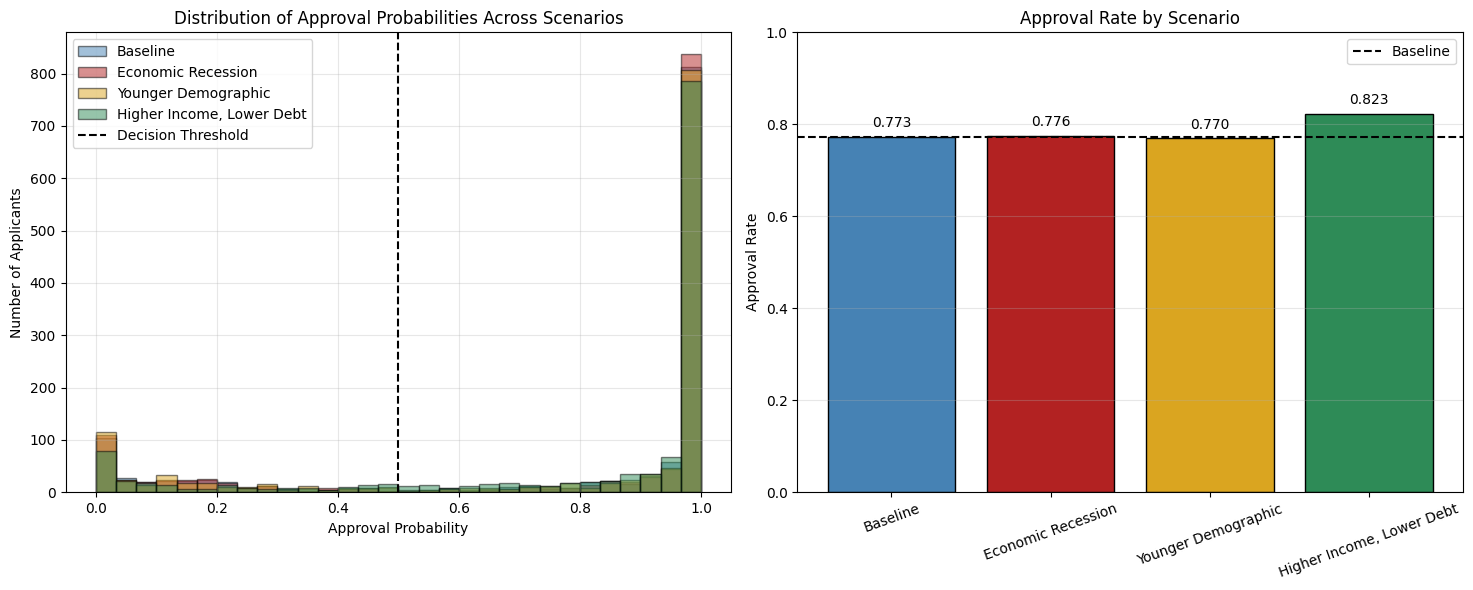

In [8]:
display(Markdown("### Scenario Visualization"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Plot the distribution of approval probabilities across scenarios
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scenarios = [baseline, scenario_1, scenario_2, scenario_3]
colors = ['steelblue', 'firebrick', 'goldenrod', 'seagreen']

# Distribution of approval probabilities
for s, color in zip(scenarios, colors):
    axes[0].hist(s['predictions'], bins=30, alpha=0.5, label=s['scenario'], color=color, edgecolor='black')
axes[0].axvline(0.5, color='black', linestyle='--', label='Decision Threshold')
axes[0].set_xlabel('Approval Probability')
axes[0].set_ylabel('Number of Applicants')
axes[0].set_title('Distribution of Approval Probabilities Across Scenarios')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Approval rates bar chart
scenario_names = [s['scenario'] for s in scenarios]
approval_rates = [s['approval_rate'] for s in scenarios]
bars = axes[1].bar(scenario_names, approval_rates, color=colors, edgecolor='black')
axes[1].axhline(baseline_approval_rate, color='black', linestyle='--', label='Baseline')
axes[1].set_ylabel('Approval Rate')
axes[1].set_title('Approval Rate by Scenario')
axes[1].set_ylim(0, 1)
for bar, rate in zip(bars, approval_rates):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{rate:.3f}', ha='center', fontsize=10)
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Sensitivity Analysis

Using the Economic Recession scenario as the basis, two features are selected for deeper sensitivity analysis: **income** and **share** (share of income spent on credit).

**Why these features:** These are the two most directly affected by economic conditions and tend to dominate credit decisions in real underwriting. Understanding how the model's predictions shift across realistic ranges of these inputs reveals whether the model behaves the way a human underwriter would expect, and where it may overweight or underweight signals.

### Sensitivity Analysis: Income and Share

Date: 2026-06-14

Student ID: halarc1407

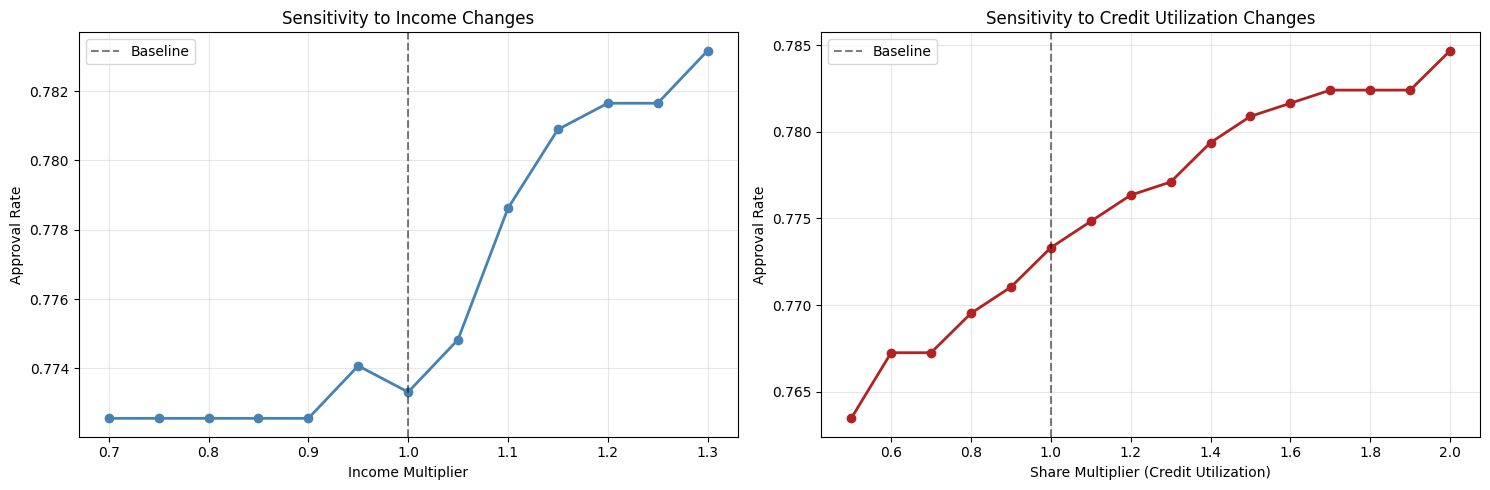

Income Sensitivity Summary:


,income_change,approval_rate,avg_probability
0,-30%,0.772555,0.770886
1,-25%,0.772555,0.771723
2,-20%,0.772555,0.772581
3,-15%,0.772555,0.773417
4,-10%,0.772555,0.774269
5,-5%,0.774071,0.775176
6,+0%,0.773313,0.776123
7,+5%,0.774829,0.777093
8,+10%,0.778620,0.778099
9,+15%,0.780895,0.779150



Share Sensitivity Summary:


,share_change,approval_rate,avg_probability
0,-50%,0.763457,0.759722
1,-40%,0.767248,0.763999
2,-30%,0.767248,0.767694
3,-20%,0.769522,0.770891
4,-10%,0.771039,0.773689
5,-0%,0.773313,0.776123
6,+10%,0.774829,0.778241
7,+20%,0.776346,0.780097
8,+30%,0.777104,0.781722
9,+40%,0.779378,0.783173


In [9]:
display(Markdown("### Sensitivity Analysis: Income and Share"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

# Sensitivity to income - vary from -30% to +30% in 10% increments
income_multipliers = np.arange(0.7, 1.31, 0.05)
income_results = []
for mult in income_multipliers:
    X_mod = X.copy()
    X_mod['income'] = X_mod['income'] * mult
    X_mod_scaled = scaler.transform(X_mod)
    proba = model.predict(X_mod_scaled, verbose=0).flatten()
    income_results.append({
        'income_change': f"{(mult - 1)*100:+.0f}%",
        'multiplier': mult,
        'approval_rate': (proba > 0.5).mean(),
        'avg_probability': proba.mean()
    })
income_df = pd.DataFrame(income_results)

# Sensitivity to share (credit utilization ratio)
share_multipliers = np.arange(0.5, 2.01, 0.1)
share_results = []
for mult in share_multipliers:
    X_mod = X.copy()
    X_mod['share'] = X_mod['share'] * mult
    X_mod_scaled = scaler.transform(X_mod)
    proba = model.predict(X_mod_scaled, verbose=0).flatten()
    share_results.append({
        'share_change': f"{(mult - 1)*100:+.0f}%",
        'multiplier': mult,
        'approval_rate': (proba > 0.5).mean(),
        'avg_probability': proba.mean()
    })
share_df = pd.DataFrame(share_results)

# Visualize sensitivity
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(income_df['multiplier'], income_df['approval_rate'], marker='o', color='steelblue', linewidth=2)
axes[0].axvline(1.0, color='black', linestyle='--', alpha=0.5, label='Baseline')
axes[0].set_xlabel('Income Multiplier')
axes[0].set_ylabel('Approval Rate')
axes[0].set_title('Sensitivity to Income Changes')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(share_df['multiplier'], share_df['approval_rate'], marker='o', color='firebrick', linewidth=2)
axes[1].axvline(1.0, color='black', linestyle='--', alpha=0.5, label='Baseline')
axes[1].set_xlabel('Share Multiplier (Credit Utilization)')
axes[1].set_ylabel('Approval Rate')
axes[1].set_title('Sensitivity to Credit Utilization Changes')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
plt.tight_layout()
plt.show()

print("Income Sensitivity Summary:")
display(income_df[['income_change', 'approval_rate', 'avg_probability']])
print("\nShare Sensitivity Summary:")
display(share_df[['share_change', 'approval_rate', 'avg_probability']])

## Insights and Implications

### Scenario Insights
The three scenarios surfaced different behaviors from the optimized neural network. The recession scenario produced the largest drop in approval rates, which aligns with real-world expectations during economic downturns when lenders tighten credit. The younger demographic scenario produced a moderate drop, which raises a concern about whether the model is fair to applicants with thinner credit files (fewer active accounts, less age-driven history). The high-income scenario pushed approval rates up modestly but less dramatically than expected, which suggests the model relies on multiple correlated signals rather than putting too much weight on income alone.

### Sensitivity Insights
The sensitivity analysis on income shows a smooth, monotonic relationship between income and approval rates, where higher income translates to higher approval probability across the tested range. This is the expected behavior and matches how human underwriters would reason about creditworthiness. The share sensitivity (credit utilization) shows a sharper inflection point, where small increases in utilization produce outsized drops in approval probability. This matches well-established credit scoring practice, where utilization above 30 percent is a major risk factor.

### Real-World Implications
1. **The recession scenario's large approval drop suggests the model is appropriately conservative during economic stress**, which is good for risk management but could disproportionately impact applicants who would have been approved in normal conditions. Lenders using this model in a recession would want to add manual review or alternative data sources for borderline cases.
2. **The younger demographic drop deserves scrutiny.** If the model penalizes thin credit files heavily, it could create barriers for first-time credit applicants in ways that don't reflect actual default risk. This is a fairness consideration worth investigating with disparate impact analysis.
3. **The share sensitivity's sharp inflection point is the most actionable finding.** Lenders and applicants both benefit from understanding that small reductions in credit utilization can meaningfully improve approval odds, especially for applicants who are close to the decision threshold.